# 패키지 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 데이터 불러오기

In [2]:
# ----------------------------------------
# 데이터를 불러와 데이터프레임을 만들고
# 상위 5개 행을 확인합니다.
# ----------------------------------------
df = pd.read_csv('data/advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


# 단순선형회귀
* TV광고량에 따른 판매량 예측

## 독립변수, 종속변수 선택
* 독립변수는 2차원으로 다룹니다.

In [11]:
X = df[['TV']]
y = df['Sales']

## 훈련세트, 테스트세트 분할
* 모듈 : `model_selection`
* 함수 : `train_test_split`

In [67]:
# ------------------------------------------
# 훈련세트, 테스트세트 분할
# ------------------------------------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((150, 1), (50, 1), (150,), (50,))

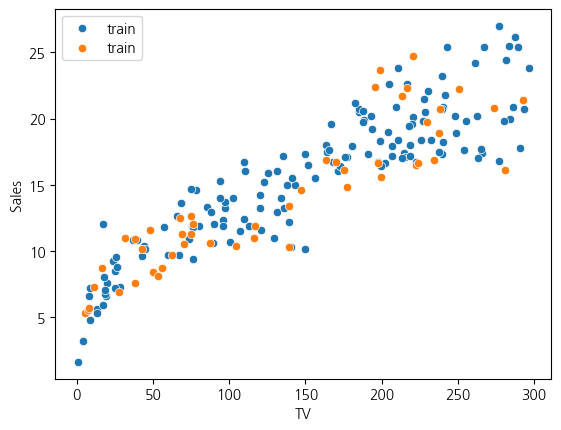

In [68]:
# ------------------------------------------
# 훈련세트, 테스트세트 분할 확인 시각화
# ------------------------------------------
sns.scatterplot(x=X_train['TV'], y=y_train, label='train')
sns.scatterplot(x=X_test['TV'], y=y_test, label='train')

plt.legend();  # 범례

## 모델 생성 및 훈련
* 선형회귀 모델
    * 모듈 : `linear_model`
    * 클래스 : `LinearRegression`

In [69]:
# ------------------------------------------
# LinearRegression 클래스 import
# ------------------------------------------
from sklearn.linear_model import LinearRegression
#from sklearn.tree import DecisionTreeClassifier

# ------------------------------------------
# 모델객체 생성하기
# ------------------------------------------
model = LinearRegression()

# ------------------------------------------
# 훈련데이터로 모델 훈련하기
# ------------------------------------------
model.fit(X_train, y_train)

LinearRegression()

## 테스트세트로 평가


In [70]:
# ------------------------------------------
# 평가 방법 선택 : MSE, MAE, RMSE, R2
# ------------------------------------------
# 평가와 관련된 모든 것은 metrics에 들어있음
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

# ------------------------------------------
# 테스트 데이터의 예측값
# y_pred
# ------------------------------------------
y_pred = model.predict(X_test)

# ------------------------------------------
# 모델 평가 
#   - 예측값과 실제값의 차이(Loss/Error) 이용
# ------------------------------------------
mse = mean_squared_error(y_test, y_pred)
print(f'mse:{mse:.4f}')

mae = mean_absolute_error(y_test, y_pred)
print(f'mae:{mae: .4f}')

rmse = root_mean_squared_error(y_test, y_pred)
print(f'rmse:{rmse:.4f}')

r2 = r2_score(y_test, y_pred)
print(f'r2:{r2:.4f}')

mse:5.5134
mae: 1.8651
rmse:2.3481
r2:0.7972


In [71]:
# ------------------------------------------
# 실제값과 모델의 예측값 비교
# ------------------------------------------
# X_test['TV']
# y_test
# y_pred
# pd.DataFrame({'X_test': X_test['TV']})

df = pd.DataFrame()
df['X_test'] = X_test['TV']
df['y_test'] = y_test
df['y_pred'] = y_pred 
df['diff'] = df['y_test'] - df['y_pred']
df.sort_index()

,X_test,y_test,y_pred,diff
9,199.8,15.6,18.165083,-2.565083
15,195.4,22.4,17.921382,4.478618
16,67.8,12.5,10.854060,1.645940
18,69.2,11.3,10.931602,0.368398
19,147.3,14.6,15.257290,-0.657290
24,62.3,9.7,10.549435,-0.849435
29,70.6,10.5,11.009143,-0.509143
30,292.9,21.4,23.321569,-1.921569
38,43.1,10.1,9.486013,0.613987
45,175.1,16.1,16.797035,-0.697035


In [72]:
# ------------------------------------------
# 회귀모델의 평가점수 수동 계산
# ------------------------------------------
df
mse = np.square(df['diff']).mean()
mae = abs(df['diff']).mean()
rmse = np.sqrt(mse)
mse, rmse, mae

(5.513351187165511, 2.3480526372220685, 1.8651146911099161)

## 모델의 학습 결과

In [73]:
# -----------------------------------------
# 회귀계수, 절편, 회귀식
# -----------------------------------------
w = model.coef_ # 가중치, 기울기
b = model.intercept_ # 절편

print(f'{w} * TV + {b}')

[0.05538653] * TV + 7.098853680118275


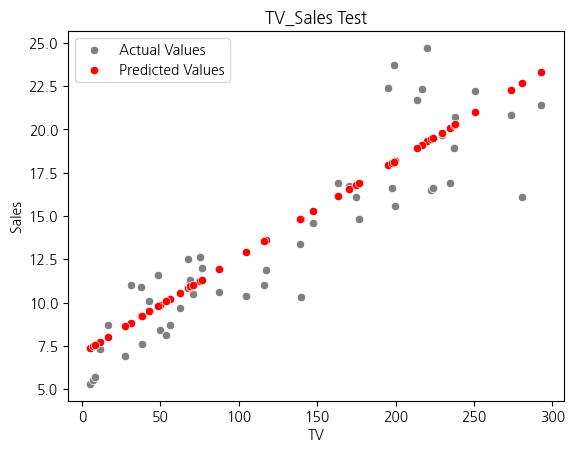

In [74]:
# ------------------------------------------
# 테스트데이터 실제값과 예측값 확인
# ------------------------------------------
sns.scatterplot(x=X_test['TV'], y=y_test, color='gray', label='Actual Values')  # 테스트데이터 실제값
sns.scatterplot(x=X_test['TV'], y=y_pred, color='red', label='Predicted Values')  # 테스트데이터 예측값
plt.xlabel('TV')
plt.title('TV_Sales Test')
pass

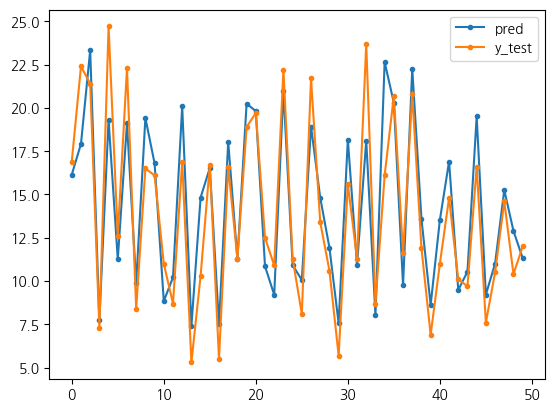

In [75]:
# ------------------------------------------
# 테스트데이터 실제값과 예측값 확인
# ------------------------------------------
plt.plot(y_pred, marker='.', label='pred')
plt.plot(np.array(y_test), marker='.', label='y_test')
plt.legend()
pass